# Hani UTR BassetBranched HPO Summary

This notebook summarizes the observed-head `BassetBranched` HPO runs for Hani Library 1 3UTR and 5UTR activity, compares the broad and focused sweeps, and evaluates selected saved checkpoints on Library 2 where the local processed files make that possible.

Key interpretive guardrails:

- Our primary HPO metric is the repo's historical flattened Pearson r squared on normalized multi-head labels (`epoch_end_val_pearson_r2`).
- Per-cell metrics are logged separately and are the better readout for cell-type-specific prediction.
- The paper-style "Average" benchmark is a different metric: average predicted activity across cell types per sequence, average true activity across cell types per sequence, then Pearson correlation across sequences. It can be much higher because it collapses cell-specific differences.
- PARADE Predictor is not the same architecture or task as this model: it is described as a LegNet-based predictor with cell type and triplet-phase inputs, and it predicts both absolute activity and activity deviation from cell-line average. Our model is a Basset-style shared convolutional trunk with one observed output head per cell type.

Paper/reference links used for context:

- Hani/Goodarzi PARADE preprint DOI page: https://doi.org/10.1101/2024.12.31.630783
- ResearchGate mirror used only for text-accessible preprint passages: https://www.researchgate.net/publication/387655881_A_generative_framework_for_enhanced_cell-type_specificity_in_rationally_designed_mRNAs
- LegNet Bioinformatics paper: https://academic.oup.com/bioinformatics/article/39/8/btad457/7230784

In [1]:
from pathlib import Path
import json
import math
import re
import sys
import tarfile
import tempfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

WORK_ROOT = Path("/home/minhang/synBio_AL")
REPO_ROOT = WORK_ROOT / "boda2_EU"
LEARN_ROOT = REPO_ROOT / "src" / "learn"
RUNS_CSV = LEARN_ROOT / "run_registry" / "runs.csv"
WANDB_LOCAL = LEARN_ROOT / "wandb"
DATA_DIR = WORK_ROOT / "opt_EU_learn_n_design" / "utr_hani_2025" / "processed_utr_data"

UTR3_WIDE = DATA_DIR / "3UTR_lib1_branched_observed_heads.csv"
UTR5_WIDE = DATA_DIR / "5UTR_lib1_branched_observed_heads.csv"
UTR3_LIB2 = DATA_DIR / "3UTR_lib2_processed.csv"
UTR5_LIB2 = DATA_DIR / "5UTR_lib2_processed.csv"
UTR3_MANIFEST = DATA_DIR / "3UTR_lib1_branched_observed_heads_manifest.json"
UTR5_MANIFEST = DATA_DIR / "5UTR_lib1_branched_observed_heads_manifest.json"

PLOT_DIR = REPO_ROOT / "tutorials" / "lib1_tasks" / "pretraining_CRE_public_data" / "presentation_plots" / "hani_utr_branched"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO_ROOT))

RUN_GROUPS = {
    "utr3__hani_rna_activity__observed_head_branched": {"region": "3UTR", "phase": "Broad Stage 1"},
    "utr3__hani_rna_activity__observed_head_branched_focused_stage2": {"region": "3UTR", "phase": "Focused Stage 2"},
    "utr5__hani_rna_activity__observed_head_branched": {"region": "5UTR", "phase": "Broad Stage 1"},
    "utr5__hani_rna_activity__observed_head_branched_focused_stage2": {"region": "5UTR", "phase": "Focused Stage 2"},
}
REGION_ORDER = ["3UTR", "5UTR"]
PHASE_ORDER = ["Broad Stage 1", "Focused Stage 2"]

## Load Registry And Manifests

The manifests are the audit trail for the observed-head preprocessing. Library 1 already had a `fold` column in the source files, and our preprocessing preserved that split when creating the wide branched tables. Library 2 does not have a train/val/test fold column; below we treat it as an external designed-library evaluation set, not part of model selection.

In [2]:
runs = pd.read_csv(RUNS_CSV)

numeric_cols = [
    "best_epoch", "best_metric_value", "val_loss", "val_r2", "val_pearson", "val_spearman",
    "test_loss", "test_r2", "test_pearson", "test_spearman",
    "train_loss", "train_r2", "train_pearson", "train_spearman",
]
for col in numeric_cols:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors="coerce")
runs["timestamp"] = pd.to_datetime(runs["timestamp"], errors="coerce")

branched_runs = runs[runs["comparison_group"].isin(RUN_GROUPS)].copy()
branched_runs["region"] = branched_runs["comparison_group"].map(lambda g: RUN_GROUPS[g]["region"])
branched_runs["phase"] = branched_runs["comparison_group"].map(lambda g: RUN_GROUPS[g]["phase"])
branched_runs["region"] = pd.Categorical(branched_runs["region"], REGION_ORDER, ordered=True)
branched_runs["phase"] = pd.Categorical(branched_runs["phase"], PHASE_ORDER, ordered=True)

manifests = {}
for name, path in {"3UTR": UTR3_MANIFEST, "5UTR": UTR5_MANIFEST}.items():
    manifests[name] = json.loads(path.read_text())

manifest_table = pd.DataFrame([
    {
        "region": region,
        "library": m["library"],
        "heads": ",".join(m["heads"]),
        "n_sequences": m["n_output_sequences"],
        "train": m["fold_counts"].get("train"),
        "val": m["fold_counts"].get("val"),
        "test": m["fold_counts"].get("test"),
    }
    for region, m in manifests.items()
])

print(f"Registry rows: {len(runs):,}")
print(f"Observed-head branched rows: {len(branched_runs):,}")
display(manifest_table)
display(
    branched_runs.groupby(["region", "phase"], observed=True)
    .agg(n_runs=("run_id", "size"), n_completed=("status", lambda s: int((s == "completed").sum())))
    .reset_index()
)

Registry rows: 341
Observed-head branched rows: 192


,region,library,heads,n_sequences,train,val,test
0,3UTR,3UTR_lib1,"c1,c2,c4,c6,c13,c17",28426,22741,2843,2842
1,5UTR,5UTR_lib1,"c1,c2,c4,c6,c17",21609,17288,2161,2160


,region,phase,n_runs,n_completed
0,3UTR,Broad Stage 1,32,32
1,3UTR,Focused Stage 2,64,64
2,5UTR,Broad Stage 1,32,32
3,5UTR,Focused Stage 2,64,64


## Broad vs Focused Sweep Results

The focused sweep fixed reverse-complement augmentation off and searched a narrower neighborhood suggested by the broad sweep. The table below ranks by the validation checkpoint metric. A second table ranks by held-out test r squared as an oracle/post-hoc view; that should not be used for model selection, but it is useful for checking whether the validation-selected model was representative.

In [3]:
def best_by(df, group_cols, metric, ascending=False):
    usable = df[df[metric].notna()].copy()
    return (
        usable.sort_values([*group_cols, metric, "timestamp"], ascending=[*[True] * len(group_cols), ascending, False])
        .groupby(group_cols, as_index=False, group_keys=False)
        .head(1)
    )

phase_summary = (
    branched_runs.groupby(["region", "phase"], observed=True)
    .agg(
        n_runs=("run_id", "size"),
        best_val_metric=("best_metric_value", "max"),
        median_val_metric=("best_metric_value", "median"),
        best_test_r2=("test_r2", "max"),
        median_test_r2=("test_r2", "median"),
        best_test_pearson=("test_pearson", "max"),
        median_test_pearson=("test_pearson", "median"),
    )
    .reset_index()
)

top_by_val = best_by(branched_runs, ["region", "phase"], "best_metric_value", ascending=False)
top_by_test = best_by(branched_runs, ["region", "phase"], "test_r2", ascending=False)

show_cols = [
    "region", "phase", "run_id", "best_epoch", "best_metric_value", "val_r2", "val_pearson",
    "test_r2", "test_pearson", "train_r2", "wandb_sweep_id", "run_url"
]

display(phase_summary.round(4))
print("Validation-selected winners")
display(top_by_val[show_cols].sort_values(["region", "phase"]).round(4))
print("Post-hoc test-r2 winners")
display(top_by_test[show_cols].sort_values(["region", "phase"]).round(4))

,region,phase,n_runs,best_val_metric,median_val_metric,best_test_r2,median_test_r2,best_test_pearson,median_test_pearson
0,3UTR,Broad Stage 1,32,0.4278,0.3065,0.4163,0.3006,0.6427,0.5457
1,3UTR,Focused Stage 2,64,0.4740,0.3961,0.4607,0.3870,0.6783,0.6222
2,5UTR,Broad Stage 1,32,0.5067,0.3371,0.4717,0.3185,0.6863,0.5641
3,5UTR,Focused Stage 2,64,0.5411,0.4852,0.5081,0.4518,0.7125,0.6715


Validation-selected winners


,region,phase,run_id,best_epoch,best_metric_value,val_r2,val_pearson,test_r2,test_pearson,train_r2,wandb_sweep_id,run_url
129,3UTR,Broad Stage 1,it06cy6q,12,0.4278,0.3706,0.6099,0.4163,0.6427,0.5207,54r4667a,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr3__hani_rna_activity__scratch__basset_branched/runs/it0...
191,3UTR,Focused Stage 2,q7bp321v,32,0.4740,0.4174,0.6475,0.4607,0.6783,0.5397,d7i45wmz,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr3__hani_rna_activity__focused__basset_branched/runs/q7b...
169,5UTR,Broad Stage 1,j4z89e01,62,0.5067,0.4858,0.6949,0.4636,0.6802,0.5787,5wraz7oh,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr5__hani_rna_activity__scratch__basset_branched/runs/j4z...
332,5UTR,Focused Stage 2,77xlfnuk,22,0.5411,0.4921,0.6999,0.4917,0.7007,0.6104,kl5k0o0u,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr5__hani_rna_activity__focused__basset_branched/runs/77x...


Post-hoc test-r2 winners


,region,phase,run_id,best_epoch,best_metric_value,val_r2,val_pearson,test_r2,test_pearson,train_r2,wandb_sweep_id,run_url
129,3UTR,Broad Stage 1,it06cy6q,12,0.4278,0.3706,0.6099,0.4163,0.6427,0.5207,54r4667a,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr3__hani_rna_activity__scratch__basset_branched/runs/it0...
191,3UTR,Focused Stage 2,q7bp321v,32,0.4740,0.4174,0.6475,0.4607,0.6783,0.5397,d7i45wmz,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr3__hani_rna_activity__focused__basset_branched/runs/q7b...
187,5UTR,Broad Stage 1,o4ipczqg,12,0.5011,0.4543,0.6715,0.4717,0.6863,0.5877,5wraz7oh,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr5__hani_rna_activity__scratch__basset_branched/runs/o4i...
280,5UTR,Focused Stage 2,pbtt9c62,9,0.5385,0.4642,0.6835,0.5081,0.7125,0.6247,kl5k0o0u,https://wandb.ai/minhangxu1998-baylor-college-of-medicine/utr5__hani_rna_activity__focused__basset_branched/runs/pbt...


best_val_metric                  best_test_r2                  \
phase    Broad Stage 1 Focused Stage 2 Broad Stage 1 Focused Stage 2   
region                                                                 
3UTR            0.4278          0.4740        0.4163          0.4607   
5UTR            0.5067          0.5411        0.4717          0.5081   

       median_test_r2                     best_val_metric             \
phase   Broad Stage 1 Focused Stage 2 Focused minus Broad Relative %   
region                                                                 
3UTR           0.3006          0.3870              0.0462    10.8069   
5UTR           0.3185          0.4518              0.0345     6.8024   

              best_test_r2                 median_test_r2             
phase  Focused minus Broad Relative % Focused minus Broad Relative %  
region                                                                
3UTR                0.0444    10.6759              0.0864    28.7324  
5UTR                0.0364     7.7171              0.1334    41.8816

PosixPath('/home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr_branched/broad_vs_focused_best_metrics.png')

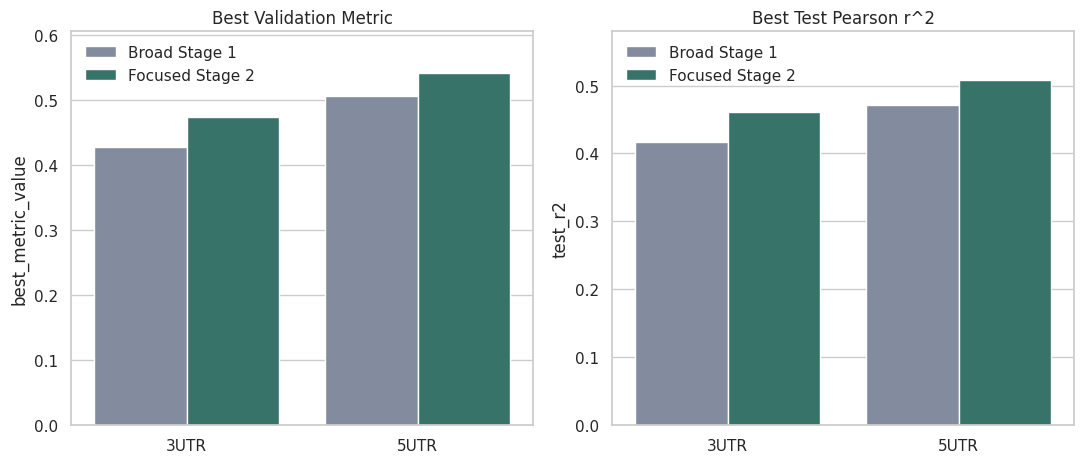

In [4]:
wide = phase_summary.pivot(index="region", columns="phase", values=["best_val_metric", "best_test_r2", "median_test_r2"])
for metric in ["best_val_metric", "best_test_r2", "median_test_r2"]:
    wide[(metric, "Focused minus Broad")] = wide[(metric, "Focused Stage 2")] - wide[(metric, "Broad Stage 1")]
    wide[(metric, "Relative %")] = 100 * wide[(metric, "Focused minus Broad")] / wide[(metric, "Broad Stage 1")]

display(wide.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=False)
for ax, metric, title in zip(axes, ["best_metric_value", "test_r2"], ["Best Validation Metric", "Best Test Pearson r^2"]):
    plot_df = best_by(branched_runs, ["region", "phase"], metric, ascending=False).copy()
    if sns:
        sns.barplot(data=plot_df, x="region", y=metric, hue="phase", ax=ax, palette=["#7E8AA2", "#2E7D6F"])
    else:
        for i, phase in enumerate(PHASE_ORDER):
            sub = plot_df[plot_df["phase"].eq(phase)]
            ax.bar(np.arange(len(sub)) + i * 0.36, sub[metric], width=0.36, label=phase)
        ax.set_xticks(np.arange(len(REGION_ORDER)) + 0.18, REGION_ORDER)
    ax.set_title(title)
    ax.set_ylim(0, max(0.58, float(plot_df[metric].max()) * 1.12))
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.legend(frameon=False)
fig.tight_layout()
plot_path = PLOT_DIR / "broad_vs_focused_best_metrics.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plot_path

## Per-Head Metrics From Local W&B Summaries

The registry stores aggregate metrics, while the W&B summary JSON files store the per-head metrics logged by `CNNBasicTraining`. These are essential because a high aggregate score can hide a weak cell type.

In [5]:
def summary_path_for_run(run_id):
    matches = sorted(WANDB_LOCAL.glob(f"run-*{run_id}/files/wandb-summary.json"))
    return matches[0] if matches else None

def load_wandb_summary(run_id):
    path = summary_path_for_run(run_id)
    if path is None:
        return {}
    return json.loads(path.read_text())

def per_head_rows(run_ids, split="test"):
    rows = []
    for run_id in run_ids:
        summary = load_wandb_summary(run_id)
        meta = branched_runs[branched_runs["run_id"].eq(run_id)].iloc[0].to_dict()
        for key, value in summary.items():
            m = re.match(fr"{split}_pearson_(c\d+)$", key)
            if not m:
                continue
            head = m.group(1)
            rows.append({
                "run_id": run_id,
                "region": meta["region"],
                "phase": meta["phase"],
                "head": head,
                f"{split}_pearson": float(value),
                f"{split}_pearson_r2": float(value) ** 2,
                f"{split}_mse": summary.get(f"{split}_mse_{head}", np.nan),
                f"{split}_spearman": summary.get(f"{split}_spearman_{head}", np.nan),
            })
    return pd.DataFrame(rows)

winner_run_ids = sorted(set(top_by_val["run_id"]).union(set(top_by_test["run_id"])))
per_head_test = per_head_rows(winner_run_ids, split="test")
per_head_val = per_head_rows(winner_run_ids, split="val")

print("Winner run ids:", ", ".join(winner_run_ids))
display(per_head_test.pivot_table(index=["region", "phase", "run_id"], columns="head", values="test_pearson").round(3))

Winner run ids: 77xlfnuk, it06cy6q, j4z89e01, o4ipczqg, pbtt9c62, q7bp321v


head                                c1    c13    c17     c2     c4     c6
region phase           run_id                                            
3UTR   Broad Stage 1   it06cy6q  0.732  0.579  0.627  0.705  0.560  0.652
       Focused Stage 2 q7bp321v  0.730  0.630  0.675  0.744  0.600  0.690
5UTR   Broad Stage 1   j4z89e01  0.706    NaN  0.671  0.715  0.588  0.721
                       o4ipczqg  0.712    NaN  0.668  0.733  0.596  0.723
       Focused Stage 2 77xlfnuk  0.725    NaN  0.688  0.747  0.604  0.740
                       pbtt9c62  0.747    NaN  0.696  0.764  0.599  0.756

PosixPath('/home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr_branched/winner_per_head_test_pearson.png')

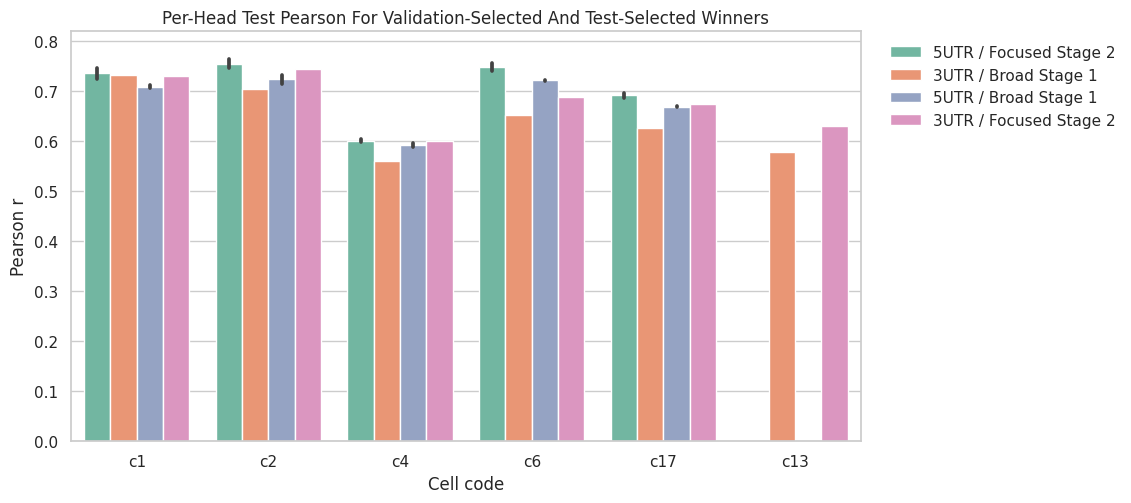

In [6]:
plot_df = per_head_test.copy()
plot_df["region_phase"] = plot_df["region"].astype(str) + " / " + plot_df["phase"].astype(str)
fig, ax = plt.subplots(figsize=(11.5, 5.2))
if sns:
    sns.barplot(data=plot_df, x="head", y="test_pearson", hue="region_phase", ax=ax, palette="Set2")
else:
    pivot = plot_df.pivot_table(index="head", columns="region_phase", values="test_pearson")
    pivot.plot(kind="bar", ax=ax)
ax.set_title("Per-Head Test Pearson For Validation-Selected And Test-Selected Winners")
ax.set_xlabel("Cell code")
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 0.82)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plot_path = PLOT_DIR / "winner_per_head_test_pearson.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plot_path

## Paper-Style Average Activity Metric And Lib2 Evaluation

The paper-style average benchmark is:

```text
y_true_avg_i = mean_c(y_true_i,c)
y_pred_avg_i = mean_c(y_pred_i,c)
r_avg = PearsonR(y_pred_avg_i, y_true_avg_i)
```

This is not the mean of per-cell Pearson correlations. Because most cell types share a global activity component, `r_avg` can look much better than the cell-type-specific metrics. It is still useful if we label it clearly, but it should sit beside per-cell metrics rather than replace them.

For this section, the notebook loads selected saved checkpoints, recomputes train-split normalization statistics from Library 1, unnormalizes predictions back to raw activity scale, and evaluates:

- Library 1 test split from the source `fold == test` rows.
- Library 2 as an external designed-library set.

Important Lib2 caveat: local 3UTR Lib2 has `c15` but not `c13`; the 3UTR BassetBranched model was trained with `c13`, not `c15`. Therefore the 3UTR Lib2 comparison uses only overlapping heads `c1,c2,c4,c6,c17` and is not a perfect six-cell PARADE comparison.

In [7]:
try:
    import torch
    from torch.utils.data import DataLoader, TensorDataset
    from boda.model.basset import BassetBranched
    from boda.common import utils as boda_utils
    TORCH_READY = True
except Exception as exc:
    TORCH_READY = False
    print("Torch/BODA imports failed; checkpoint evaluation cells will be skipped.")
    print(repr(exc))

BIN_COLUMNS = ["1", "2", "3", "4"]

def pearson_np(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    corr = np.corrcoef(a[mask], b[mask])[0, 1]
    return float(corr) if np.isfinite(corr) else np.nan

def aggregate_processed_library(path, heads, require_all=False):
    df = pd.read_csv(path)
    for col in BIN_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    keep = df[df["cell_type"].isin(heads)].dropna(subset=["seq", "cell_type", *BIN_COLUMNS]).copy()
    group_cols = ["seq", "cell_type"] + (["fold"] if "fold" in keep.columns else [])
    grouped = keep.groupby(group_cols, observed=True)[BIN_COLUMNS].sum().reset_index()
    denom = grouped[BIN_COLUMNS].sum(axis=1)
    grouped = grouped[denom > 0].copy()
    denom = denom[denom > 0]
    grouped["rna_activity"] = (grouped["1"] + 2 * grouped["2"] + 3 * grouped["3"] + 4 * grouped["4"]) / denom
    index_cols = ["seq"] + (["fold"] if "fold" in grouped.columns else [])
    wide = grouped.pivot_table(index=index_cols, columns="cell_type", values="rna_activity", aggfunc="first").reset_index()
    for head in heads:
        if head not in wide.columns:
            wide[head] = np.nan
    if require_all:
        wide = wide.dropna(subset=heads).copy()
    return wide[["seq"] + (["fold"] if "fold" in wide.columns else []) + list(heads)]

def load_artifact_model(artifact_path):
    with tempfile.TemporaryDirectory() as tmp:
        with tarfile.open(artifact_path) as tar:
            tar.extractall(tmp)
        ckpt = torch.load(Path(tmp) / "artifacts" / "torch_checkpoint.pt", map_location="cpu")
    model = BassetBranched(**vars(ckpt["model_hparams"]))
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, vars(ckpt["data_hparams"]), vars(ckpt["model_hparams"])

def predict_sequences(model, seqs, batch_size=512):
    x = torch.stack([boda_utils.dna2tensor(seq) for seq in seqs])
    loader = DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=False)
    preds = []
    with torch.no_grad():
        for (batch_x,) in loader:
            preds.append(model(batch_x).cpu())
    return torch.cat(preds, dim=0).numpy()

def evaluate_artifact(run_id, artifact_path, lib1_wide_path, lib2_processed_path):
    model, data_hparams, model_hparams = load_artifact_model(artifact_path)
    heads = list(data_hparams["activity_columns"])
    lib1 = pd.read_csv(lib1_wide_path)
    train = lib1[lib1["fold"].eq("train")]
    means = train[heads].mean()
    stds = train[heads].std().replace(0, 1.0)

    eval_sets = [
        ("lib1_test", lib1[lib1["fold"].eq("test")].copy(), heads),
        ("lib2_overlap", aggregate_processed_library(lib2_processed_path, heads, require_all=False), None),
    ]
    rows = []
    per_head = []
    for split, df, available_heads in eval_sets:
        if available_heads is None:
            available_heads = [h for h in heads if h in df.columns and df[h].notna().sum() >= 2]
            df = df.dropna(subset=available_heads).copy()
        pred_norm = predict_sequences(model, df["seq"].tolist(), batch_size=int(data_hparams.get("batch_size", 512)))
        pred_norm = pd.DataFrame(pred_norm, columns=heads, index=df.index)
        pred_raw = pred_norm.mul(stds, axis=1).add(means, axis=1)
        true_raw = df[heads].astype(float)

        pearsons = []
        for head in available_heads:
            r = pearson_np(pred_raw[head], true_raw[head])
            pearsons.append(r)
            per_head.append({
                "run_id": run_id,
                "split": split,
                "head": head,
                "pearson": r,
                "pearson_r2": r ** 2 if np.isfinite(r) else np.nan,
            })

        flat_r = pearson_np(pred_raw[available_heads].to_numpy().ravel(), true_raw[available_heads].to_numpy().ravel())
        avg_r = pearson_np(pred_raw[available_heads].mean(axis=1), true_raw[available_heads].mean(axis=1))
        rows.append({
            "run_id": run_id,
            "split": split,
            "n_sequences": len(df),
            "heads_used": ",".join(available_heads),
            "n_heads": len(available_heads),
            "mean_per_head_pearson": float(np.nanmean(pearsons)),
            "mean_per_head_pearson_r2": float(np.nanmean(pearsons)) ** 2,
            "flattened_raw_pearson": flat_r,
            "flattened_raw_pearson_r2": flat_r ** 2 if np.isfinite(flat_r) else np.nan,
            "average_activity_pearson": avg_r,
            "average_activity_pearson_r2": avg_r ** 2 if np.isfinite(avg_r) else np.nan,
            "model_params": int(sum(p.numel() for p in model.parameters())),
            "model_hparams": model_hparams,
        })
    return rows, per_head

In [8]:
if TORCH_READY:
    selected = pd.concat([top_by_val, top_by_test], ignore_index=True).drop_duplicates("run_id")
    selected = selected[selected["artifact_path"].notna() & selected["artifact_path"].astype(str).ne("")].copy()

    eval_rows = []
    eval_per_head_rows = []
    for row in selected.itertuples(index=False):
        region = str(row.region)
        lib1_path = UTR3_WIDE if region == "3UTR" else UTR5_WIDE
        lib2_path = UTR3_LIB2 if region == "3UTR" else UTR5_LIB2
        rows, per_head_rows = evaluate_artifact(row.run_id, row.artifact_path, lib1_path, lib2_path)
        for out in rows:
            out.update({"region": region, "phase": str(row.phase), "selection_source": "selected winner"})
        for out in per_head_rows:
            out.update({"region": region, "phase": str(row.phase)})
        eval_rows.extend(rows)
        eval_per_head_rows.extend(per_head_rows)

    checkpoint_eval = pd.DataFrame(eval_rows)
    checkpoint_eval_per_head = pd.DataFrame(eval_per_head_rows)
    display_cols = [
        "region", "phase", "run_id", "split", "n_sequences", "heads_used", "mean_per_head_pearson",
        "flattened_raw_pearson", "average_activity_pearson", "model_params"
    ]
    display(checkpoint_eval[display_cols].sort_values(["region", "phase", "run_id", "split"]).round(4))
else:
    checkpoint_eval = pd.DataFrame()
    checkpoint_eval_per_head = pd.DataFrame()

,region,phase,run_id,split,n_sequences,heads_used,mean_per_head_pearson,flattened_raw_pearson,average_activity_pearson,model_params
0,3UTR,Broad Stage 1,it06cy6q,lib1_test,2842,"c1,c2,c4,c6,c13,c17",0.6427,0.6501,0.7327,1032360
1,3UTR,Broad Stage 1,it06cy6q,lib2_overlap,5675,"c1,c2,c4,c6,c17",0.4210,0.4059,0.5071,1032360
2,3UTR,Focused Stage 2,q7bp321v,lib1_test,2842,"c1,c2,c4,c6,c13,c17",0.6783,0.6819,0.7748,1921254
3,3UTR,Focused Stage 2,q7bp321v,lib2_overlap,5675,"c1,c2,c4,c6,c17",0.4780,0.4483,0.5677,1921254
4,5UTR,Broad Stage 1,j4z89e01,lib1_test,2160,"c1,c2,c4,c6,c17",0.6802,0.6779,0.7611,321902
5,5UTR,Broad Stage 1,j4z89e01,lib2_overlap,10175,"c1,c2,c4,c6,c17",0.3914,0.3762,0.5182,321902
8,5UTR,Broad Stage 1,o4ipczqg,lib1_test,2160,"c1,c2,c4,c6,c17",0.6863,0.6804,0.7640,387114
9,5UTR,Broad Stage 1,o4ipczqg,lib2_overlap,10175,"c1,c2,c4,c6,c17",0.3247,0.3047,0.4160,387114
6,5UTR,Focused Stage 2,77xlfnuk,lib1_test,2160,"c1,c2,c4,c6,c17",0.7007,0.6964,0.7808,694056
7,5UTR,Focused Stage 2,77xlfnuk,lib2_overlap,10175,"c1,c2,c4,c6,c17",0.4609,0.4469,0.6118,694056


PosixPath('/home/minhang/synBio_AL/boda2_EU/tutorials/lib1_tasks/pretraining_CRE_public_data/presentation_plots/hani_utr_branched/average_vs_per_head_metric.png')

head                                             c1    c13    c17     c2  \
region phase           run_id   split                                      
3UTR   Broad Stage 1   it06cy6q lib1_test     0.732  0.579  0.627  0.705   
                                lib2_overlap  0.394    NaN  0.387  0.499   
       Focused Stage 2 q7bp321v lib1_test     0.730  0.630  0.675  0.744   
                                lib2_overlap  0.537    NaN  0.387  0.551   
5UTR   Broad Stage 1   j4z89e01 lib1_test     0.706    NaN  0.671  0.715   
                                lib2_overlap  0.464    NaN  0.447  0.387   
                       o4ipczqg lib1_test     0.712    NaN  0.668  0.733   
                                lib2_overlap  0.403    NaN  0.366  0.345   
       Focused Stage 2 77xlfnuk lib1_test     0.725    NaN  0.688  0.747   
                                lib2_overlap  0.528    NaN  0.526  0.456   
                       pbtt9c62 lib1_test     0.747    NaN  0.696  0.764   
                                lib2_overlap  0.527    NaN  0.501  0.449   

head                                             c4     c6  
region phase           run_id   split                       
3UTR   Broad Stage 1   it06cy6q lib1_test     0.560  0.652  
                                lib2_overlap  0.427  0.399  
       Focused Stage 2 q7bp321v lib1_test     0.600  0.690  
                                lib2_overlap  0.438  0.477  
5UTR   Broad Stage 1   j4z89e01 lib1_test     0.588  0.721  
                                lib2_overlap  0.373  0.286  
                       o4ipczqg lib1_test     0.596  0.723  
                                lib2_overlap  0.294  0.216  
       Focused Stage 2 77xlfnuk lib1_test     0.604  0.740  
                                lib2_overlap  0.445  0.349  
                       pbtt9c62 lib1_test     0.599  0.756  
                                lib2_overlap  0.417  0.327

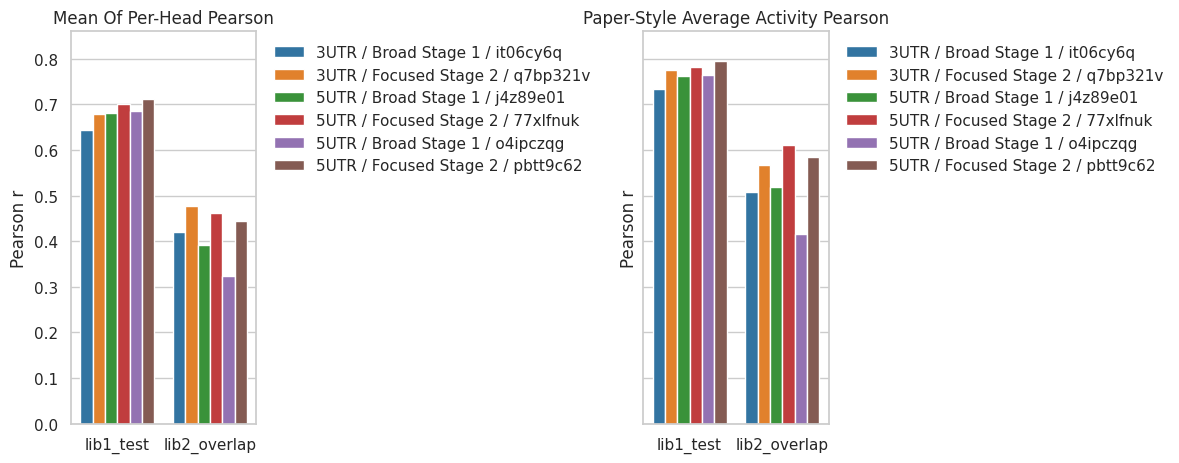

In [9]:
if not checkpoint_eval.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
    plot_df = checkpoint_eval[checkpoint_eval["split"].isin(["lib1_test", "lib2_overlap"])].copy()
    plot_df["label"] = plot_df["region"] + " / " + plot_df["phase"].astype(str) + " / " + plot_df["run_id"]
    for ax, metric, title in zip(
        axes,
        ["mean_per_head_pearson", "average_activity_pearson"],
        ["Mean Of Per-Head Pearson", "Paper-Style Average Activity Pearson"],
    ):
        if sns:
            sns.barplot(data=plot_df, x="split", y=metric, hue="label", ax=ax, palette="tab10")
        else:
            plot_df.pivot_table(index="split", columns="label", values=metric).plot(kind="bar", ax=ax)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("Pearson r")
        ax.set_ylim(0, 0.86)
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    plot_path = PLOT_DIR / "average_vs_per_head_metric.png"
    fig.savefig(plot_path, dpi=180, bbox_inches="tight")
    display(plot_path)

    display(
        checkpoint_eval_per_head
        .pivot_table(index=["region", "phase", "run_id", "split"], columns="head", values="pearson")
        .round(3)
    )

## Compare To PARADE/LegNet Paper Benchmarks

This table is intentionally conservative. The cleanest comparison is the absolute activity prediction metric for Library 1 and Library 2. The delta-activity, tau/specificity, CTAD, and generative-design claims are not apples-to-apples because our model was not trained with those targets and was not used to select designed sequences.

The PARADE preprint reports cell-specific absolute activity Pearson ranges of roughly 0.65-0.79 for 5UTR and 0.65-0.75 for 3UTR on Library 1, and Library 2 predictor-vs-measured activity ranges of roughly 0.39-0.62 for 5UTR and 0.65-0.70 for 3UTR. Those are ranges from figure/text descriptions, not exact downloadable per-cell numbers.

In [10]:
paper_reference = pd.DataFrame([
    {
        "benchmark": "PARADE Lib1 cell-specific absolute activity",
        "region": "5UTR",
        "paper_reported_r": "0.65-0.79",
        "paper_context": "Training/evaluation in PARADE Predictor figure/text; includes LegNet-style inputs and delta objective.",
        "comparison_quality": "Partial: same biological Library 1 concept, but not necessarily identical split/objective/features.",
    },
    {
        "benchmark": "PARADE Lib1 cell-specific absolute activity",
        "region": "3UTR",
        "paper_reported_r": "0.65-0.75",
        "paper_context": "Training/evaluation in PARADE Predictor figure/text; includes LegNet-style inputs and delta objective.",
        "comparison_quality": "Partial: same biological Library 1 concept, but not necessarily identical split/objective/features.",
    },
    {
        "benchmark": "PARADE Lib2 predictor vs measured activity",
        "region": "5UTR",
        "paper_reported_r": "0.39-0.62",
        "paper_context": "Designed Library 2 external validation; passed QC sequences reported as 10,174.",
        "comparison_quality": "Closer as external holdout activity prediction, but our model was selected on Lib1 and lacks PARADE features.",
    },
    {
        "benchmark": "PARADE Lib2 predictor vs measured activity",
        "region": "3UTR",
        "paper_reported_r": "0.65-0.70",
        "paper_context": "Designed Library 2 external validation; passed QC sequences reported as 5,675.",
        "comparison_quality": "Weak for our current 3UTR Lib2 because local labels have c15 but not c13, so only overlapping heads are evaluated.",
    },
])

display(paper_reference)

if not checkpoint_eval.empty:
    # Validation-selected focused model for each region is the honest HPO-selected summary.
    val_selected_focused = top_by_val[top_by_val["phase"].astype(str).eq("Focused Stage 2")][["region", "run_id"]]
    honest = checkpoint_eval.merge(val_selected_focused, on=["region", "run_id"], how="inner")
    display(
        honest[["region", "run_id", "split", "n_sequences", "heads_used", "mean_per_head_pearson", "average_activity_pearson"]]
        .sort_values(["region", "split"])
        .round(4)
    )

,benchmark,region,paper_reported_r,paper_context,comparison_quality
0,PARADE Lib1 cell-specific absolute activity,5UTR,0.65-0.79,Training/evaluation in PARADE Predictor figure/text; includes LegNet-style inputs and delta objective.,"Partial: same biological Library 1 concept, but not necessarily identical split/objective/features."
1,PARADE Lib1 cell-specific absolute activity,3UTR,0.65-0.75,Training/evaluation in PARADE Predictor figure/text; includes LegNet-style inputs and delta objective.,"Partial: same biological Library 1 concept, but not necessarily identical split/objective/features."
2,PARADE Lib2 predictor vs measured activity,5UTR,0.39-0.62,"Designed Library 2 external validation; passed QC sequences reported as 10,174.","Closer as external holdout activity prediction, but our model was selected on Lib1 and lacks PARADE features."
3,PARADE Lib2 predictor vs measured activity,3UTR,0.65-0.70,"Designed Library 2 external validation; passed QC sequences reported as 5,675.","Weak for our current 3UTR Lib2 because local labels have c15 but not c13, so only overlapping heads are evaluated."


,region,run_id,split,n_sequences,heads_used,mean_per_head_pearson,average_activity_pearson
0,3UTR,q7bp321v,lib1_test,2842,"c1,c2,c4,c6,c13,c17",0.6783,0.7748
1,3UTR,q7bp321v,lib2_overlap,5675,"c1,c2,c4,c6,c17",0.4780,0.5677
2,5UTR,77xlfnuk,lib1_test,2160,"c1,c2,c4,c6,c17",0.7007,0.7808
3,5UTR,77xlfnuk,lib2_overlap,10175,"c1,c2,c4,c6,c17",0.4609,0.6118


## Architecture And Parameter Count

Our `BassetBranched` differs from LegNet/PARADE in several material ways:

- BassetBranched: three padded 1D convolution blocks, max pooling, one or more dense layers, then grouped/branched dense layers with one scalar output per observed cell-type head.
- PARADE Predictor/LegNet: LegNet is an EfficientNetV2-inspired fully convolutional architecture with residual channel-wise concatenation, squeeze-excitation style blocks, global average pooling, and soft-classification/soft-argmax output in the original promoter model. The PARADE Predictor adapts LegNet with one-hot UTR sequence plus extra cell-type/triplet-phase channels and predicts absolute activity plus activity deviation from the cell-line average.
- The parameter count is therefore not the whole story. Our best UTR3 model is close to original LegNet scale, while our UTR5 models are smaller, but PARADE's adapted predictor may differ from the original LegNet count.

In [11]:
if not checkpoint_eval.empty:
    param_table = (
        checkpoint_eval[["region", "phase", "run_id", "model_params"]]
        .drop_duplicates()
        .sort_values(["region", "phase", "run_id"])
    )
    legnet_reference = pd.DataFrame([
        {"model": "Original LegNet", "params": 1_852_846, "source_note": "Bioinformatics LegNet paper, original model."},
        {"model": "Optimized LegNet", "params": 2_100_000, "source_note": "Bioinformatics LegNet paper reports about 2.1M parameters."},
    ])
    display(param_table)
    display(legnet_reference)

,region,phase,run_id,model_params
0,3UTR,Broad Stage 1,it06cy6q,1032360
2,3UTR,Focused Stage 2,q7bp321v,1921254
4,5UTR,Broad Stage 1,j4z89e01,321902
8,5UTR,Broad Stage 1,o4ipczqg,387114
6,5UTR,Focused Stage 2,77xlfnuk,694056
10,5UTR,Focused Stage 2,pbtt9c62,656330


,model,params,source_note
0,Original LegNet,1852846,"Bioinformatics LegNet paper, original model."
1,Optimized LegNet,2100000,Bioinformatics LegNet paper reports about 2.1M parameters.


## Critical Readout

- Focused HPO improved both regions versus the initial broad sweep. For UTR3, the focused validation-selected winner improved Library 1 test Pearson r from about 0.643 to 0.678. For UTR5, the focused post-hoc best test winner improved test Pearson r from about 0.686 to 0.712, and the validation-selected focused winner still improved over the broad validation-selected test result.
- The "Average" activity metric is worth reporting, but only as a separate aggregate. In our recomputation it is indeed higher than the mean of per-cell Pearson. That confirms your concern: it is easier because it rewards the global shared activity component and suppresses cell-type-specific errors.
- Lib2 evaluation can be achieved in this notebook for our saved best models. It is strongest for 5UTR because the same five observed heads are present. The local complete-overlap 5UTR Lib2 count is 10,175, while the paper text reports 10,174 QC-passing sequences, so treat that one-sequence discrepancy as a preprocessing/QC audit item before making a formal table.
- For 3UTR Lib2 the comparison is weaker because Lib1 trained `c13`, while Lib2 has `c15`; the notebook evaluates only overlapping heads.
- Direct comparison to PARADE is partial. Absolute activity prediction is comparable in spirit, but PARADE also predicts activity deviation and specificity-related quantities, uses different inputs/features, and evaluates designed Library 2 sequences produced by its own generator.

Next practical step: after reviewing this notebook, a useful follow-up would be to add an explicit delta-from-average target/head to our branched model and run a small focused HPO variant. That would move the comparison closer to the PARADE predictor task without jumping architectures yet.